# SensorGen Inference Demo

This notebook demonstrates the two released **SensorGen** checkpoints:

- `text2ecg.pt` — Text-to-ECG generation (MIMIC-IV ECG)
- `bp_translation.pt` — Invasive blood-pressure reconstruction (VitalDB)

The figures below were rendered from qualitative examples and
are saved inline in this notebook.

To reproduce with your own data,
set `RUN_MODEL=True` and edit the paths in `configs/<task>.yaml`.

## 1. Checkpoint setup

`RUN_MODEL=False` (default) renders the preselected example arrays if present. Set `RUN_MODEL=True` to
download the checkpoints from Hugging Face and run inference on your own data.

In [1]:
import json, os
import numpy as np
import matplotlib
matplotlib.use('Agg')  # headless-safe; remove for interactive plots
import matplotlib.pyplot as plt

HF_REPO_ID    = 'yang-ai-lab/SensorGen'
TEXT2ECG_CKPT = 'text2ecg.pt'
BP_CKPT       = 'bp_translation.pt'
RUN_MODEL     = False   # default: no download, no model

SAMPLE_DIR = 'examples/sample_data'
if not os.path.isdir(SAMPLE_DIR) and os.path.isdir('sample_data'):
    SAMPLE_DIR = 'sample_data'
T2E_NPZ = os.path.join(SAMPLE_DIR, 'text2ecg_selected_samples.npz')
BP_NPZ  = os.path.join(SAMPLE_DIR, 'bp_translation_selected_samples.npz')
print('config: HF_REPO_ID=%s  RUN_MODEL=%s' % (HF_REPO_ID, RUN_MODEL))

config: HF_REPO_ID=yang-ai-lab/SensorGen  RUN_MODEL=False


## 2. Data shapes

Expected array layout for each task's sample data (documents the input/output
format for the checkpoints).

In [91]:
# Text-to-ECG: input (raw) vs. generated array shapes (from the actual arrays)
if os.path.exists(T2E_NPZ):
    z = np.load(T2E_NPZ, allow_pickle=True)
    print('Text-to-ECG (MIMIC-IV ECG)')
    print('  %-30s | %-30s' % ('raw / input', 'generated'))
    print('  %-30s | %-30s' % ('report: %d text prompts' % len(z['reports']),
                               'generated_ecg %s' % (z['generated_ecg'].shape,)))
else:
    print('Text-to-ECG: sample arrays not shipped in this repo.')

Text-to-ECG (MIMIC-IV ECG)
  raw / input                    | generated                     
  report: 2 text prompts         | generated_ecg (2, 12, 1000)   


In [92]:
# BP reconstruction: raw (real) vs. generated array shapes (from the actual arrays)
if os.path.exists(BP_NPZ):
    z = np.load(BP_NPZ, allow_pickle=True)
    print('BP reconstruction (VitalDB)')
    print('  %-30s | %-30s' % ('raw / real', 'generated'))
    print('  %-30s | %-30s' % ('real_abp %s' % (z['real_abp'].shape,),
                               'generated_abp %s' % (z['generated_abp'].shape,)))
    print('  input: ppg_condition %s' % (z['ppg_condition'].shape,))
else:
    print('BP reconstruction: sample arrays not shipped in this repo.')

BP reconstruction (VitalDB)
  raw / real                     | generated                     
  real_abp (2, 1, 1500)          | generated_abp (2, 1, 1500)    
  input: ppg_condition (2, 1, 1500)


## 3. Text-to-ECG example

A generated 12-lead ECG from `text2ecg.pt`.

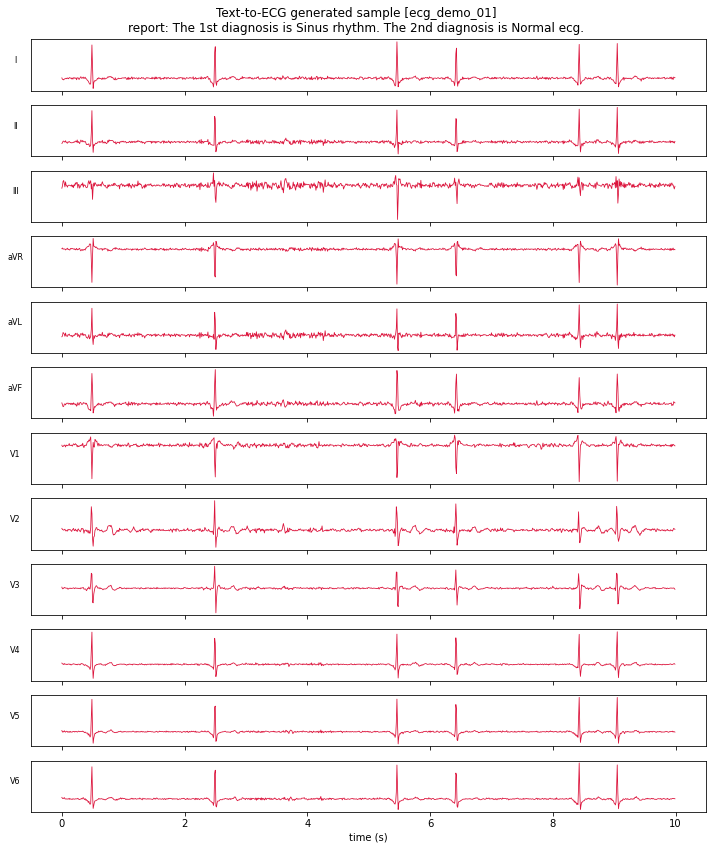

In [93]:
LEADS = ['I','II','III','aVR','aVL','aVF','V1','V2','V3','V4','V5','V6']
if os.path.exists(T2E_NPZ):
    z = np.load(T2E_NPZ, allow_pickle=True)
    gen = z['generated_ecg']; reports = [str(x) for x in z['reports']]; ids = [str(s) for s in z['public_sample_ids']]
    i = 0; ecg = gen[i]; t = np.arange(ecg.shape[1]) / 100.0
    fig, axes = plt.subplots(12, 1, figsize=(10, 12), sharex=True)
    for L in range(12):
        axes[L].plot(t, ecg[L], color='crimson', lw=0.8)
        axes[L].set_ylabel(LEADS[L], rotation=0, labelpad=16, fontsize=8); axes[L].set_yticks([])
    axes[-1].set_xlabel('time (s)')
    fig.suptitle('Text-to-ECG generated sample [%s]\nreport: %s' % (ids[i], reports[i]))
    plt.tight_layout(); plt.show()
else:
    print('text2ecg sample not shipped; run: python -m sensorgen.inference --task text2ecg ...')

## 4. BP reconstruction example

PPG input, and real vs. generated arterial blood pressure (ABP) from
`bp_translation.pt`.

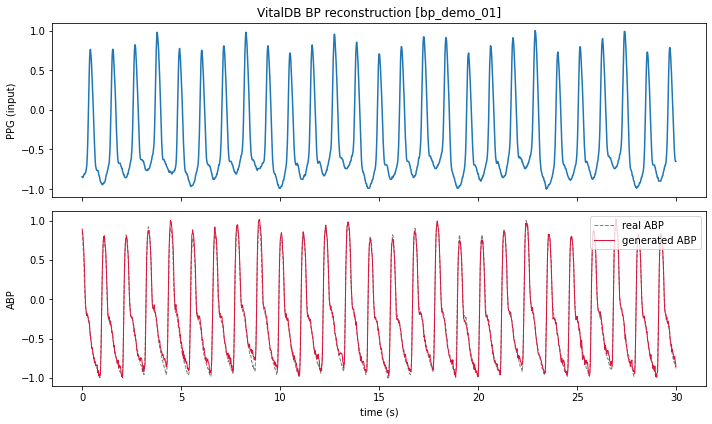

In [99]:
if os.path.exists(BP_NPZ):
    z = np.load(BP_NPZ, allow_pickle=True)
    ppg = z['ppg_condition']; real = z['real_abp']; gen = z['generated_abp']
    ids = [str(s) for s in z['public_sample_ids']]
    i = 0; t = np.arange(1500) / 50.0
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
    ax1.plot(t, ppg[i, 0], color='tab:blue'); ax1.set_ylabel('PPG (input)')
    ax1.set_title('VitalDB BP reconstruction [%s]' % ids[i])
    ax2.plot(t, real[i, 0], color='gray', ls='--', lw=1.0, label='real ABP')
    ax2.plot(t, gen[i, 0], color='crimson', lw=1.0, label='generated ABP')
    ax2.set_ylabel('ABP'); ax2.set_xlabel('time (s)'); ax2.legend(loc='upper right')
    plt.tight_layout(); plt.show()
else:
    print('bp sample not shipped; run: python -m sensorgen.inference --task bp_translation ...')

## 5. Optional: run the model (`RUN_MODEL=True`)

Downloads the checkpoints from Hugging Face. Full inference also needs the
sensorgen package and your own prepared data (edit `configs/<task>.yaml`);
Text-to-ECG additionally needs access to the SD3 text encoder on Hugging Face.

In [5]:
if RUN_MODEL:
    from huggingface_hub import hf_hub_download
    t2e_ckpt = hf_hub_download(repo_id=HF_REPO_ID, filename=TEXT2ECG_CKPT)
    bp_ckpt  = hf_hub_download(repo_id=HF_REPO_ID, filename=BP_CKPT)
    print('Downloaded:', t2e_ckpt); print('Downloaded:', bp_ckpt)
    os.makedirs('outputs/notebook_bp_translation', exist_ok=True)
    print('Then: python -m sensorgen.inference --task bp_translation \\')
    print('        --checkpoint %s --config configs/bp_translation.yaml \\' % bp_ckpt)
    print('        --output_dir outputs/notebook_bp_translation')
else:
    print('RUN_MODEL=False -> skipped checkpoint download and model inference.')

RUN_MODEL=False -> skipped checkpoint download and model inference.
